# CDS303 Session 2 : Python Implementation

## Setup

In [4]:
# data pre-processing
import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, accuracy_score, classification_report, ConfusionMatrixDisplay
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

# data mining
from sklearn.decomposition import PCA

# visualization
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns

import warnings
warnings.filterwarnings(action = 'ignore')

## 1. Data pre-processing: stock

### 1.1 Load dataset

In [5]:
file_name = 'stock portfolio performance data set.xlsx'
stock = pd.read_excel(file_name,
                      index_col=0,               # having the first column as an index
                      skiprows=1,                # skips the first row of the file 
                      sheet_name='all period')   # selects the exact sheet number
                                                                                     
stock # 9-dimensions

,Large B/P,Large ROE,Large S/P,Large Return Rate in the last quarter,Large Market Value,Small systematic Risk,Annual Return,Excess Return,Systematic Risk,Total Risk,Abs. Win Rate,Rel. Win Rate,Annual Return.1,Excess Return.1,Systematic Risk.1,Total Risk.1,Abs. Win Rate.1,Rel. Win Rate.1
ID,,,,,,,,,,,,,,,,,,
1,1.000,0.000,0.000,0.000,0.000,0.000,0.139,0.010,1.33,0.149,0.663,0.525,0.531875,0.478116,0.738015,0.800000,0.52,0.411765
2,0.000,1.000,0.000,0.000,0.000,0.000,0.143,0.010,1.17,0.108,0.663,0.650,0.549712,0.487595,0.571579,0.412231,0.52,0.764706
3,0.000,0.000,1.000,0.000,0.000,0.000,0.173,0.018,1.30,0.144,0.638,0.513,0.692625,0.629895,0.703051,0.756879,0.44,0.376471
4,0.000,0.000,0.000,1.000,0.000,0.000,0.096,-0.002,1.39,0.144,0.613,0.475,0.324351,0.255634,0.800000,0.756046,0.36,0.270588
5,0.000,0.000,0.000,0.000,1.000,0.000,0.096,0.001,1.04,0.087,0.725,0.538,0.326615,0.306501,0.432452,0.209289,0.72,0.447059
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59,0.200,0.200,0.200,0.000,0.200,0.200,0.171,0.022,0.94,0.100,0.700,0.638,0.685397,0.706792,0.322843,0.329431,0.64,0.729412
60,0.200,0.200,0.000,0.200,0.200,0.200,0.153,0.018,0.88,0.087,0.725,0.638,0.595786,0.631599,0.259952,0.204156,0.72,0.729412
61,0.200,0.000,0.200,0.200,0.200,0.200,0.156,0.018,0.97,0.104,0.663,0.525,0.612546,0.631119,0.359730,0.368958,0.52,0.411765


### 1.2 Select numerical variables

In [6]:
# selects columns with numerical types
stock_nums = stock.select_dtypes(include=['number'])

### 1.3 Standardize the dataset

In [7]:
# mean = 0, std = 1
stock_st = StandardScaler().fit_transform(stock_nums)
stock_st = pd.DataFrame(stock_st,
                        columns = stock_nums.columns,
                        index=stock_nums.index)                        
stock_st.head(10)

,Large B/P,Large ROE,Large S/P,Large Return Rate in the last quarter,Large Market Value,Small systematic Risk,Annual Return,Excess Return,Systematic Risk,Total Risk,Abs. Win Rate,Rel. Win Rate,Annual Return.1,Excess Return.1,Systematic Risk.1,Total Risk.1,Abs. Win Rate.1,Rel. Win Rate.1
ID,,,,,,,,,,,,,,,,,,
1,4.215035,-0.842718,-0.842718,-0.842718,-0.842718,-0.842718,-0.370273,-0.673769,2.643154,3.013612,-0.412338,-0.864659,-0.364910,-0.721222,2.657200,3.011505,-0.419859,-0.860534
2,-0.842718,4.215035,-0.842718,-0.842718,-0.842718,-0.842718,-0.225608,-0.673769,1.205324,0.118796,-0.412338,1.365669,-0.230085,-0.651500,1.237544,0.151089,-0.419859,1.370480
3,-0.842718,-0.842718,4.215035,-0.842718,-0.842718,-0.842718,0.859377,0.461948,2.373561,2.660586,-1.128360,-1.078771,0.850181,0.395165,2.358968,2.693422,-1.134753,-1.083636
4,-0.842718,-0.842718,-0.842718,4.215035,-0.842718,-0.842718,-1.925418,-2.377344,3.182340,2.660586,-1.844383,-1.756790,-1.933551,-2.357656,3.185916,2.687278,-1.849647,-1.752940
5,-0.842718,-0.842718,-0.842718,-0.842718,4.215035,-0.842718,-1.925418,-1.951451,0.037087,-1.363914,1.363398,-0.632705,-1.916441,-1.983515,0.050822,-1.345934,1.367377,-0.637433
6,-0.842718,-0.842718,-0.842718,-0.842718,-0.842718,4.215035,-2.865739,-2.803238,0.576273,0.260007,-3.276428,-1.970902,-2.873505,-2.766864,0.549219,0.275250,-3.279436,-1.976042
7,1.686158,1.686158,-0.842718,-0.842718,-0.842718,-0.842718,1.655033,1.597666,-0.591964,-0.093020,1.735729,1.151557,1.661810,1.646347,-0.569288,-0.122140,1.724824,1.147379
8,1.686158,-0.842718,1.686158,-0.842718,-0.842718,-0.842718,0.533882,0.178019,2.553290,3.013612,-0.784670,-1.078771,0.544505,0.132545,2.534714,2.990811,-0.777306,-1.083636
9,-0.842718,1.686158,1.686158,-0.842718,-0.842718,-0.842718,1.293371,1.029807,0.216816,0.189401,-0.068647,1.365669,1.288559,1.066305,0.236411,0.196134,-0.062411,1.370480


### 1.4 Correlation analysis

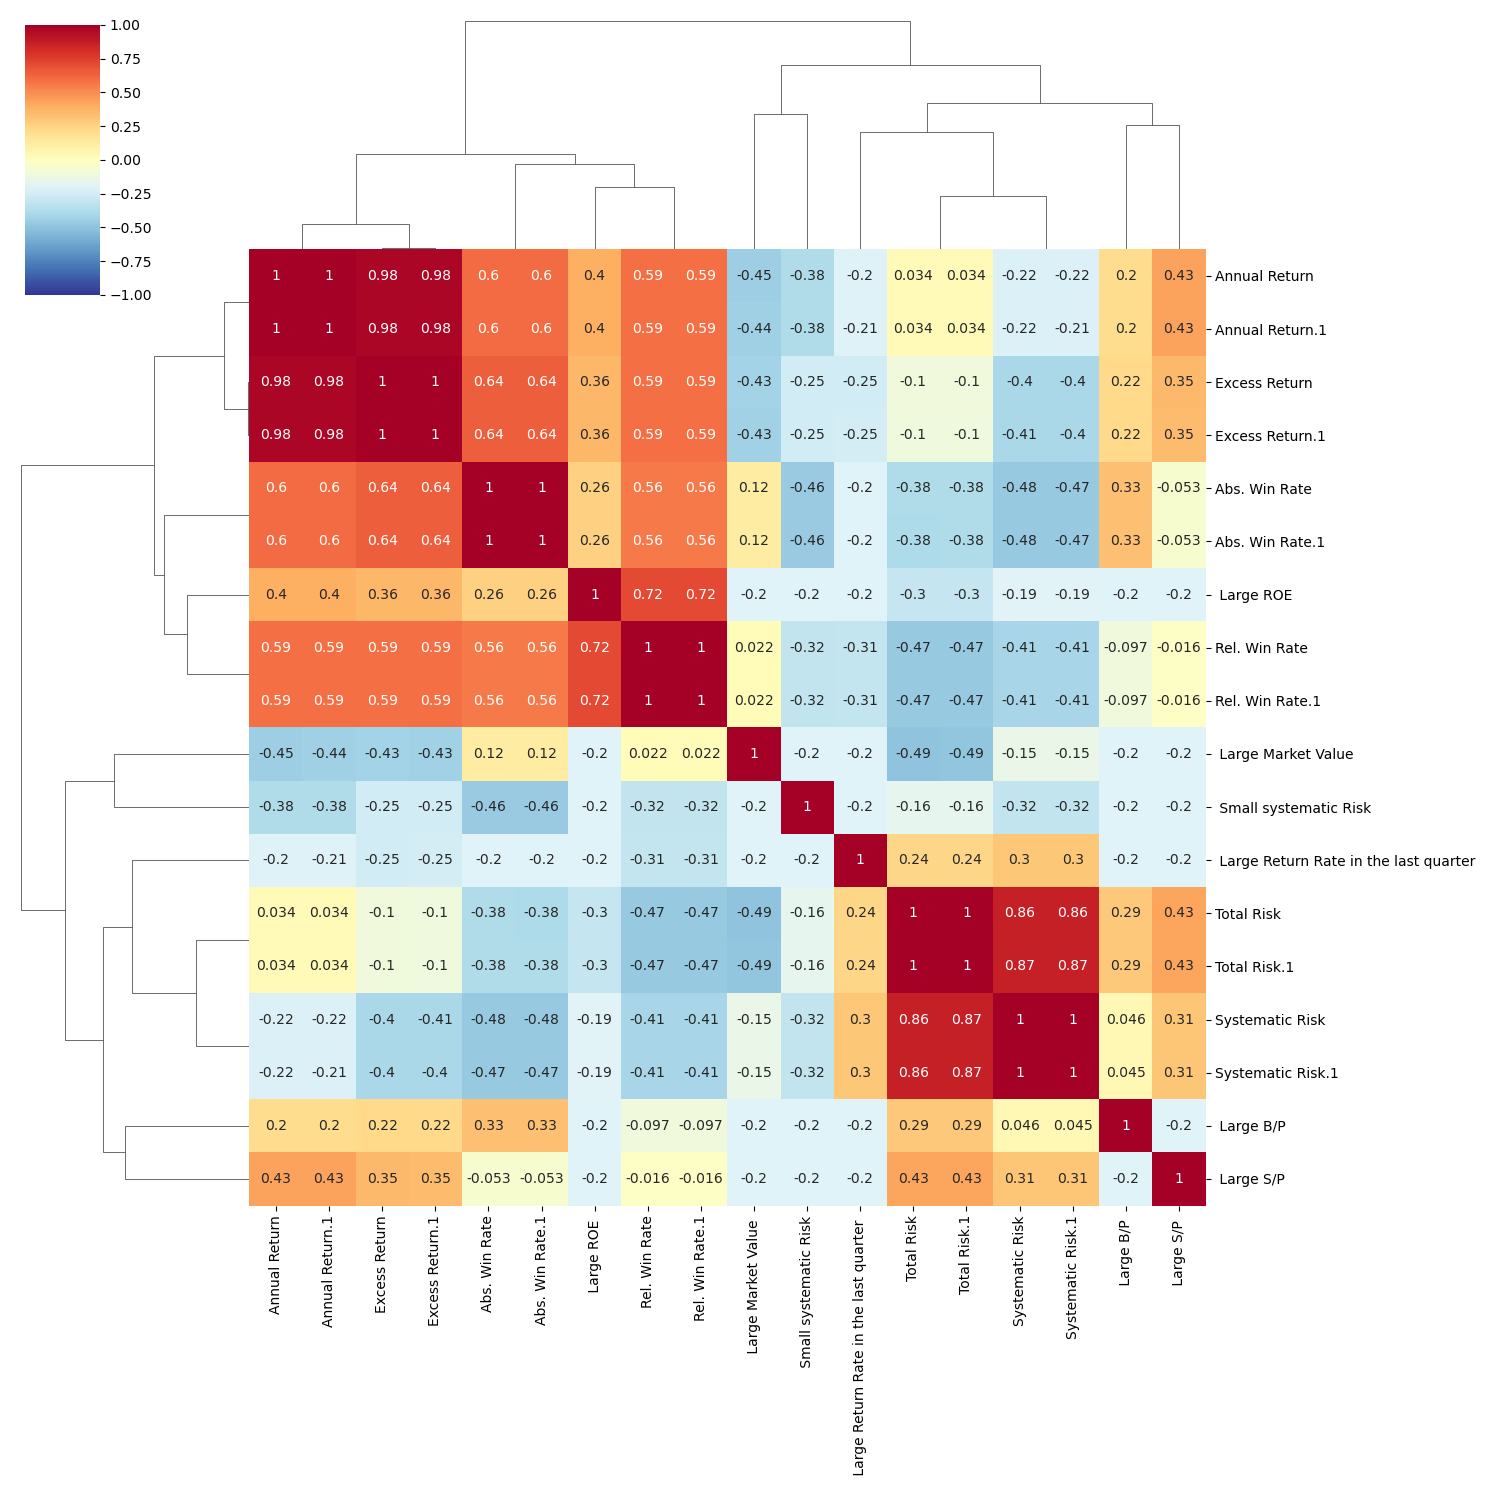

In [8]:
# correlation between attributes
cor = stock_st.corr()

sns.clustermap(cor, annot = True, cmap = 'RdYlBu_r',vmin = -1, vmax = 1,figsize=(15,15))
plt.show()

## 2. Dimensionality reduction using PCA

### 2.1 PCA model construction

In [9]:
pca = PCA(random_state = 2000, n_components = None)
pca.fit_transform(stock_st)

array([[-3.59232597e+00,  4.47826201e+00, -1.57643959e+00, ...,
        -4.87143365e-04, -5.13726365e-04,  7.67231900e-05],
       [ 4.31740660e-01,  2.73599595e-01, -1.62500993e+00, ...,
        -9.63029518e-04, -6.81992253e-04,  7.37802299e-04],
       [-2.56163685e+00,  5.87060324e+00,  7.21417508e-01, ...,
        -1.31690562e-03,  1.51628208e-03,  4.22974190e-04],
       ...,
       [-2.23749263e-01, -1.10568358e-01,  1.08336555e+00, ...,
        -5.81720342e-03, -3.05206224e-03,  1.41587626e-03],
       [ 2.21221317e+00, -8.94496469e-01, -6.83447519e-02, ...,
        -8.58834711e-03,  7.50075775e-04, -4.40044706e-04],
       [ 3.57258040e+00, -5.80797093e-01,  1.06153043e-01, ...,
        -3.26619259e-03,  3.94094168e-03,  3.06934334e-03]],
      shape=(63, 18))

### 2.2 Explained variance analysis

In [10]:
# variance or eigenvalues
pca.explained_variance_

array([7.52266236e+00, 4.30460012e+00, 1.78271650e+00, 1.72066033e+00,
       1.22791667e+00, 1.03189408e+00, 2.98479959e-01, 2.54532107e-01,
       1.19302399e-01, 2.55450744e-02, 1.33105061e-03, 3.06943803e-04,
       1.67866551e-04, 1.39080926e-04, 4.22642967e-05, 1.66488572e-05,
       8.12592493e-06, 1.00085608e-06])

In [11]:
pca.explained_variance_ratio_

array([4.11291946e-01, 2.35348507e-01, 9.74677450e-02, 9.40749031e-02,
       6.71347740e-02, 5.64174896e-02, 1.63190101e-02, 1.39162175e-02,
       6.52270610e-03, 1.39664428e-03, 7.27734900e-05, 1.67817599e-05,
       9.17788904e-06, 7.60407178e-06, 2.31074638e-06, 9.10254980e-07,
       4.44274555e-07, 5.47205266e-08])

In [12]:
# variance ratio
exp_variance_ratio = pca.explained_variance_ratio_

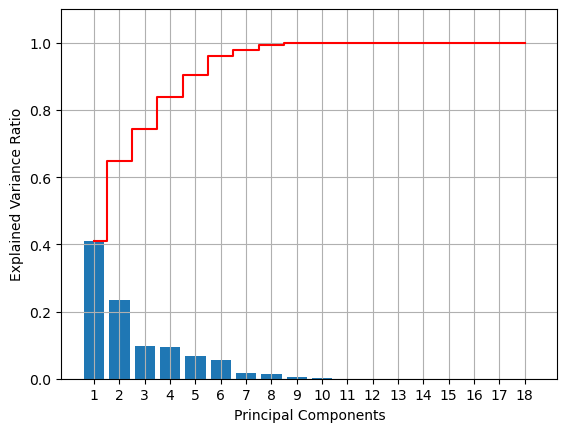

In [13]:
def explained_variance_ratio_plot(exp_variance_ratio):
    x_axis = range(1, len(exp_variance_ratio)+1)
    plt.bar(x_axis, exp_variance_ratio,
            align = 'center', label = 'Individual Explained Variance Ratio')
    plt.step(x_axis, np.cumsum(exp_variance_ratio),
             where = 'mid', color='red', label='Cumulative Explained Variance Ratio')
    plt.ylim(0, 1.1)
    plt.xticks(x_axis)
    plt.xlabel('Principal Components')
    plt.ylabel('Explained Variance Ratio')
    plt.grid()
    plt.show()
   
explained_variance_ratio_plot(exp_variance_ratio)

### 2.3 PCA loadings analysis

In [14]:
loadings = pca.components_

In [15]:
num_pc = pca.components_.shape[1]
pc_list = ["PC"+str(i) for i in list(range(1, num_pc+1))]

loadings_df = pd.DataFrame.from_dict(dict(zip(pc_list, loadings)))
loadings_df['variable'] = stock.columns.values
loadings_df = loadings_df.set_index('variable')
loadings_df

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12,PC13,PC14,PC15,PC16,PC17,PC18
variable,,,,,,,,,,,,,,,,,,
Large B/P,0.043827,0.156470,-0.070920,0.567200,-0.241830,-0.456437,-0.350585,-0.119740,0.223854,-0.160142,0.015795,-0.003785,0.007459,0.001652,-0.006869,-0.002543,0.044717,0.405776
Large ROE,0.203733,-0.019955,-0.095192,-0.470624,-0.318114,-0.278512,0.467367,-0.361694,0.116969,0.137349,-0.006645,0.003124,0.000289,-0.004609,-0.009072,-0.002192,0.043922,0.406065
Large S/P,0.021457,0.300600,0.143227,-0.134161,0.631433,0.180372,0.027810,0.075206,0.511598,-0.066736,0.007213,-0.005984,0.001138,-0.002478,-0.007917,-0.001464,0.044044,0.405845
Large Return Rate in the last quarter,-0.132059,0.063066,-0.159433,-0.042801,-0.472991,0.717555,-0.190363,0.099404,0.002771,0.000672,-0.000242,-0.001362,0.006304,-0.001497,-0.006438,-0.003054,0.043720,0.405701
Large Market Value,-0.032294,-0.298057,-0.422477,0.084074,0.453953,-0.009856,-0.119779,-0.156976,-0.504425,0.239454,-0.031539,0.003538,0.007647,-0.004045,-0.008962,-0.003687,0.043958,0.405603
Small systematic Risk,-0.104608,-0.202099,0.604655,-0.003786,-0.052475,-0.153235,0.165099,0.465577,-0.351042,-0.149574,0.013918,-0.002108,0.009509,0.006676,-0.007697,-0.003487,0.043857,0.405470
Annual Return,0.298280,0.266938,0.095439,-0.016345,0.026077,0.079942,-0.043767,-0.150658,-0.262724,-0.219154,-0.298815,-0.121906,0.099727,-0.379811,-0.629295,0.164170,-0.014275,-0.011827
Excess Return,0.318117,0.200467,0.178863,0.051241,0.013197,0.092377,-0.067869,-0.127044,-0.185648,0.171657,0.836605,-0.155508,0.021979,-0.074849,0.010868,0.008664,-0.015495,0.001615
Systematic Risk,-0.236157,0.308025,-0.260457,-0.154389,0.019817,-0.116094,0.073636,0.090022,-0.189221,-0.378474,0.253495,0.618052,-0.250131,-0.190831,-0.025848,-0.059438,-0.041575,0.008486


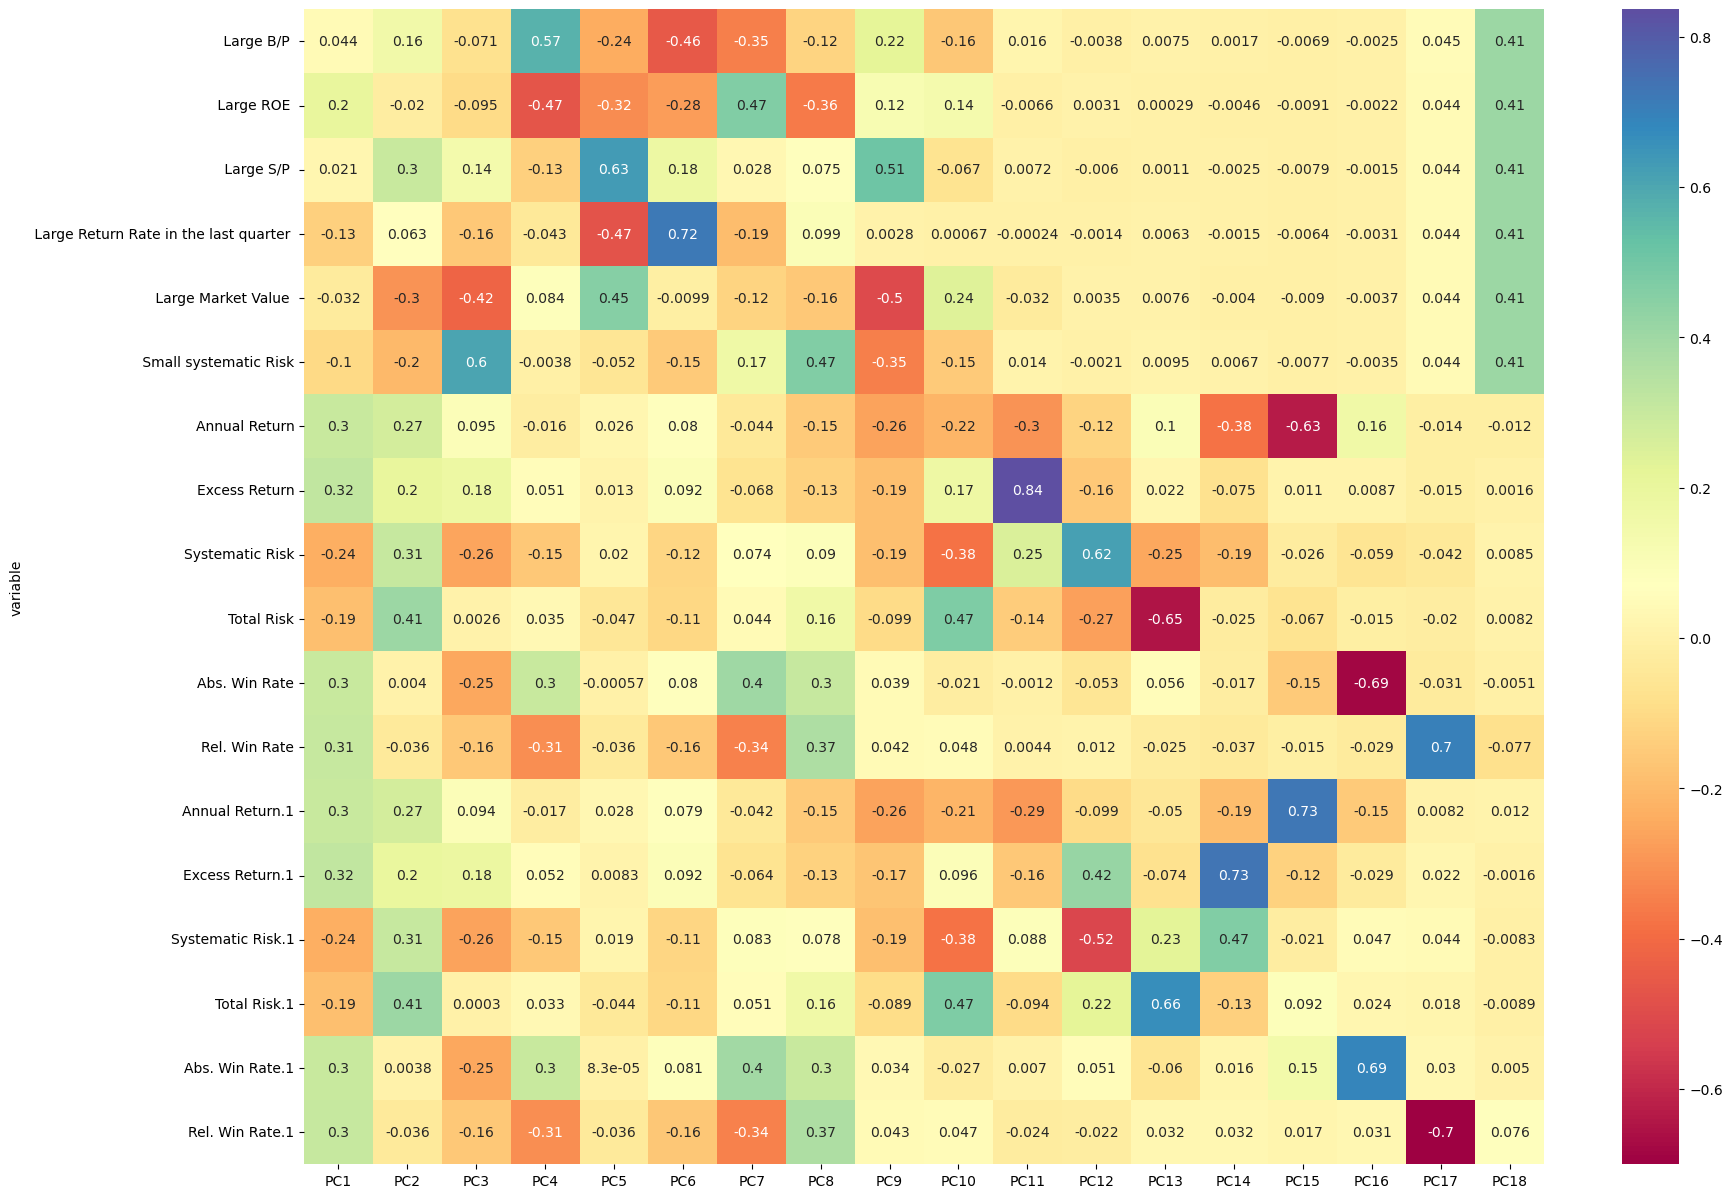

In [16]:
plt.figure(figsize=(20,15))
ax = sns.heatmap(loadings_df, annot=True, cmap='Spectral')
plt.show()
# can browse characteristics of each principal component

### 2.4 PCA scores analysis

In [17]:
pca.transform(stock_st)

array([[-3.59232597e+00,  4.47826201e+00, -1.57643959e+00, ...,
        -4.87143365e-04, -5.13726365e-04,  7.67231900e-05],
       [ 4.31740660e-01,  2.73599595e-01, -1.62500993e+00, ...,
        -9.63029518e-04, -6.81992253e-04,  7.37802299e-04],
       [-2.56163685e+00,  5.87060324e+00,  7.21417508e-01, ...,
        -1.31690562e-03,  1.51628208e-03,  4.22974190e-04],
       ...,
       [-2.23749263e-01, -1.10568358e-01,  1.08336555e+00, ...,
        -5.81720342e-03, -3.05206224e-03,  1.41587626e-03],
       [ 2.21221317e+00, -8.94496469e-01, -6.83447519e-02, ...,
        -8.58834711e-03,  7.50075775e-04, -4.40044706e-04],
       [ 3.57258040e+00, -5.80797093e-01,  1.06153043e-01, ...,
        -3.26619259e-03,  3.94094168e-03,  3.06934334e-03]],
      shape=(63, 18))

In [18]:
scores = pca.transform(stock_st).transpose()

In [19]:
num_pc = pca.components_.shape[1]
pc_list = ["PC"+ str(i) for i in list(range(1, num_pc+1))]
scores_df = pd.DataFrame.from_dict(dict(zip(pc_list, scores)))
scores_df['stock'] = stock.index
scores_df = scores_df.set_index('stock')
scores_df

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12,PC13,PC14,PC15,PC16,PC17,PC18
stock,,,,,,,,,,,,,,,,,,
1,-3.592326,4.478262,-1.576440,2.485271,-1.364897,-3.544787,-0.691617,0.222051,-0.103186,-0.053064,0.049308,-0.015454,0.015782,0.019258,0.001615,-0.000487,-0.000514,0.000077
2,0.431741,0.273600,-1.625010,-3.914845,-1.698598,-2.380062,1.409375,-0.591323,0.543474,-0.031321,-0.007259,-0.002646,0.012776,0.002379,-0.006433,-0.000963,-0.000682,0.000738
3,-2.561637,5.870603,0.721418,-1.210675,3.177200,0.170588,0.471253,-0.196119,0.411293,0.102585,0.050602,0.008865,0.005658,-0.002739,-0.012242,-0.001317,0.001516,0.000423
4,-8.002677,2.609055,-2.204226,-1.202786,-2.538231,1.841612,-0.005764,0.682503,-0.126843,0.245494,-0.012051,0.020185,0.016575,0.024056,-0.006773,-0.000376,-0.002554,0.000031
5,-1.646895,-4.346991,-3.724728,1.392223,2.319190,-0.014451,1.220064,0.206814,-0.560665,0.076105,0.001684,-0.000646,0.003599,0.001951,0.000434,0.001033,0.002607,0.000209
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59,2.910252,-0.230652,0.437150,0.026564,0.466897,-0.380813,-0.453829,0.352823,-0.211060,0.236362,0.039703,-0.001501,-0.007981,-0.008546,0.006174,0.001848,0.001351,0.000175
60,3.027773,-2.130619,-0.278355,0.613670,-0.636215,0.390392,-0.144587,0.761676,0.251343,-0.057091,0.071499,-0.003928,-0.013278,0.001016,-0.011633,0.005371,0.000699,-0.000015
61,-0.223749,-0.110568,1.083366,0.973363,0.399084,0.778131,-0.400073,-0.854835,-0.252680,0.093021,0.039927,-0.016802,0.006209,0.003845,-0.000104,-0.005817,-0.003052,0.001416


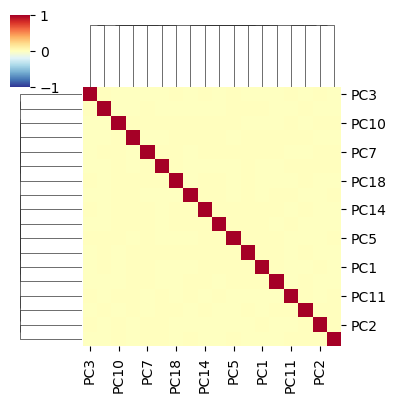

In [20]:
# Confirm that principal components are independent of each other
cor = scores_df.corr()
sns.clustermap(cor, annot = False, cmap = 'RdYlBu_r',vmin = -1, vmax = 1,figsize=(4,4))

### 2.5 PCA biplot visualization

In [21]:
# biplot: https://sukhbinder.wordpress.com/2015/08/05/biplot-with-python/
def biplot(score, coeff, pcax, pcay, labels=None):
  pca1 = pcax - 1
  pca2 = pcay - 1
    
  xs = score[:,pca1]
  ys = score[:,pca2]
    
  scalex = 1.0/(xs.max()- xs.min())
  scaley = 1.0/(ys.max()- ys.min())
    
  plt.figure(figsize=(8, 6))  
  plt.scatter(xs*scalex, ys*scaley, alpha = 0.5)

  n = coeff.shape[0]
  for i in range(n):
    plt.arrow(0, 0, coeff[i,pca1], coeff[i,pca2],color='r',alpha=0.5)
    if labels is None:
      plt.text(coeff[i,pca1]* 1.15, coeff[i,pca2] * 1.15, "Var"+str(i+1), color='g', ha='center', va='center')
    else:
      plt.text(coeff[i,pca1]* 1.15, coeff[i,pca2] * 1.15, labels[i], color='g', ha='center', va='center')
  plt.xlim(-1,1)
  plt.ylim(-1,1)
    
  plt.xlabel(f"PC{pcax} ({pca.explained_variance_ratio_[pca1]*100:.2f} %)")
  plt.ylabel(f"PC{pcay} ({pca.explained_variance_ratio_[pca2]*100:.2f} %)")
  plt.grid()

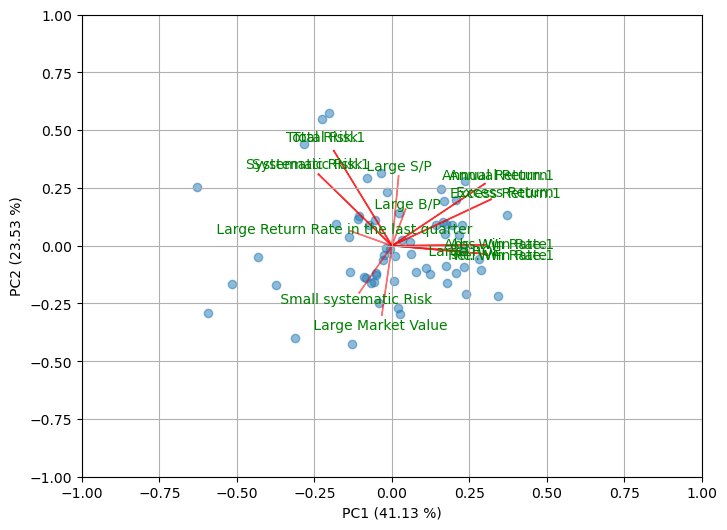

In [22]:
scores = pca.transform(stock_st)
biplot(scores, pca.components_.T, 1, 2, labels=stock.columns)

## 3. Clustering analysis

### 3.1 Select performance indicators

In [23]:
# selects performance indicators based on the paper's methodology
performance_cols = [
    'Annual Return',
    'Excess Return',
    'Systematic Risk',
    'Total Risk',
    'Abs. Win Rate',
    'Rel. Win Rate'
]

performance_data = stock[performance_cols]

### 3.2 Standardize performance indicators

In [24]:
performance_st = StandardScaler().fit_transform(performance_data)
performance_st = pd.DataFrame(performance_st,
                              columns=performance_cols,
                              index=stock.index)

performance_st.head()

,Annual Return,Excess Return,Systematic Risk,Total Risk,Abs. Win Rate,Rel. Win Rate
ID,,,,,,
1,-0.370273,-0.673769,2.643154,3.013612,-0.412338,-0.864659
2,-0.225608,-0.673769,1.205324,0.118796,-0.412338,1.365669
3,0.859377,0.461948,2.373561,2.660586,-1.128360,-1.078771
4,-1.925418,-2.377344,3.182340,2.660586,-1.844383,-1.756790
5,-1.925418,-1.951451,0.037087,-1.363914,1.363398,-0.632705


### 3.3 Try different numbers of clusters & Silhouette score

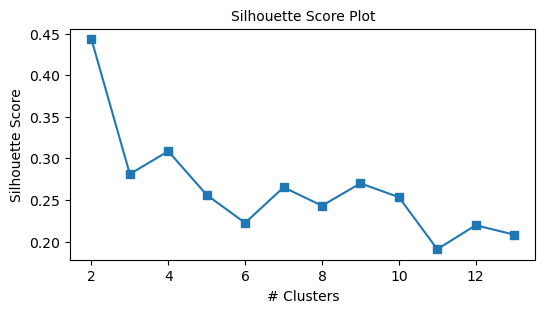

In [25]:
kmeans = KMeans()

scores = []
cluster_results = {}
for _n_clusters in np.arange(2, 14):
    kmeans.n_clusters = _n_clusters
    cluster_results[_n_clusters] = kmeans.fit_predict(performance_st)
    scores.append(silhouette_score(performance_st, kmeans.labels_))
    
plt.figure(figsize=(6, 3))
plt.title('Silhouette Score Plot', fontsize=10)
plt.xlabel('# Clusters', fontsize=10)
plt.ylabel('Silhouette Score', fontsize=10)
plt.plot(np.arange(2, 14), scores, marker='s')
plt.show()

In [26]:
# highest silhouette score : k=4
# 4 clusters has the best seperation

### 3.4 Apply final K-means clustering

In [27]:
kmeans = KMeans(n_clusters=4, random_state=2020)

performance_fit = kmeans.fit(performance_st)

clusters = performance_fit.labels_
centers = performance_fit.cluster_centers_

### 3.5 Add cluster labels to original dataset

In [28]:
# adds cluster labels to the original dataset
# in order to interpret the group features by sorting into similar portfolio
stock_clustered = stock.copy()
stock_clustered['Cluster'] = clusters

stock_clustered.head()

,Large B/P,Large ROE,Large S/P,Large Return Rate in the last quarter,Large Market Value,Small systematic Risk,Annual Return,Excess Return,Systematic Risk,Total Risk,Abs. Win Rate,Rel. Win Rate,Annual Return.1,Excess Return.1,Systematic Risk.1,Total Risk.1,Abs. Win Rate.1,Rel. Win Rate.1,Cluster
ID,,,,,,,,,,,,,,,,,,,
1,1.0,0.0,0.0,0.0,0.0,0.0,0.139,0.010,1.33,0.149,0.663,0.525,0.531875,0.478116,0.738015,0.800000,0.52,0.411765,2
2,0.0,1.0,0.0,0.0,0.0,0.0,0.143,0.010,1.17,0.108,0.663,0.650,0.549712,0.487595,0.571579,0.412231,0.52,0.764706,1
3,0.0,0.0,1.0,0.0,0.0,0.0,0.173,0.018,1.30,0.144,0.638,0.513,0.692625,0.629895,0.703051,0.756879,0.44,0.376471,2
4,0.0,0.0,0.0,1.0,0.0,0.0,0.096,-0.002,1.39,0.144,0.613,0.475,0.324351,0.255634,0.800000,0.756046,0.36,0.270588,2
5,0.0,0.0,0.0,0.0,1.0,0.0,0.096,0.001,1.04,0.087,0.725,0.538,0.326615,0.306501,0.432452,0.209289,0.72,0.447059,1


### 3.6 Cluster standardized mean

In [29]:
# standardizes mean by cluster
# in order to compare indicators on the same scale
performance_st_clustered = performance_st.copy()
performance_st_clustered['Cluster'] = clusters

cluster_means_st = performance_st_clustered.groupby('Cluster').mean()
cluster_means_st

,Annual Return,Excess Return,Systematic Risk,Total Risk,Abs. Win Rate,Rel. Win Rate
Cluster,,,,,,
0,0.576623,0.784595,-1.098472,-0.882515,1.011896,1.028281
1,-0.703002,-0.654840,-0.031809,-0.189514,-0.491578,-0.504238
2,-0.225608,-0.602786,2.688086,2.837099,-1.042438,-1.194748
3,0.869423,0.745878,0.126951,0.224704,0.432568,0.477503


### 3.7 Visualize clusters using PCA

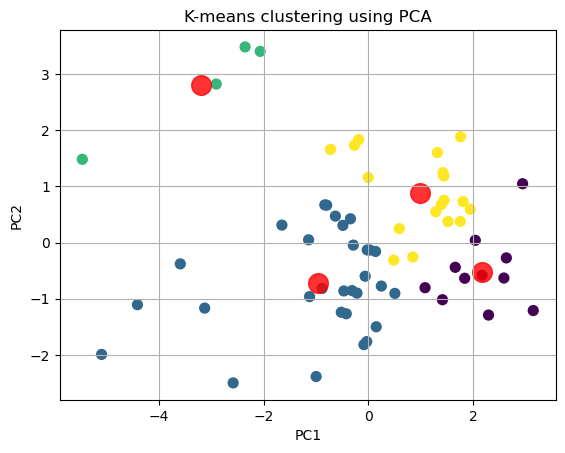

In [30]:
# applies PCA to reduce the 6-dimensional performance data
# into 2 principal components for visualization

pca_perf = PCA(n_components=2)

performance_pca = pca_perf.fit_transform(performance_st)
centers_pca = pca_perf.transform(centers)

plt.scatter(performance_pca[:,0], performance_pca[:,1], c=clusters, s=50, cmap='viridis')

plt.scatter(centers_pca[:,0], centers_pca[:,1], c='red', s=200, alpha=0.8)

plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('K-means clustering using PCA')
plt.grid()
plt.show()

## 4. Classification

### 4.1 Use cluster labels as target

In [31]:
x = performance_st
y = pd.DataFrame(clusters, columns = ['Cluster'])

print(x.shape)
print(y.shape)

(63, 6)
(63, 1)


### 4.2 Train-test split

In [32]:
x_train, x_test, y_train, y_test = train_test_split(x, y, stratify = y, test_size = 0.3, random_state = 2020)

print(x_train.shape)
print(x_test.shape)

(44, 6)
(19, 6)


### 4.3 Random forest classification

In [33]:
rfc = RandomForestClassifier(n_estimators = 100, n_jobs = -1, random_state = 2020)

rfc.fit(x_train, y_train.values.ravel())

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


### 4.4 Classification performance

Training Accuracy: 1.000
Testing Accuracy: 0.947
              precision    recall  f1-score   support

           0       1.00      0.67      0.80         3
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00         1
           3       0.86      1.00      0.92         6

    accuracy                           0.95        19
   macro avg       0.96      0.92      0.93        19
weighted avg       0.95      0.95      0.94        19



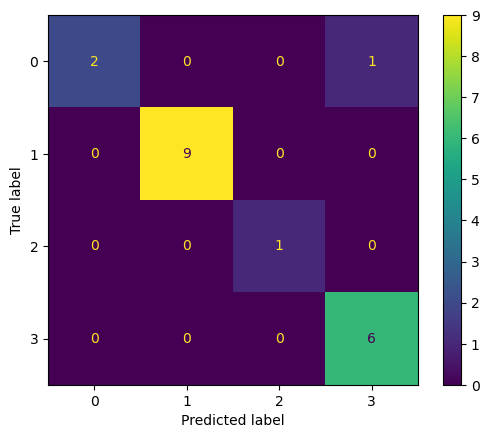

In [34]:
# training set
y_train_pred = rfc.predict(x_train)
print('Training Accuracy: {:.3f}'.format(accuracy_score(y_train, y_train_pred)))

# testing set
y_test_pred = rfc.predict(x_test)
print('Testing Accuracy: {:.3f}'.format(accuracy_score(y_test, y_test_pred)))

print(classification_report(y_test, y_test_pred))
ConfusionMatrixDisplay.from_predictions(y_test, y_test_pred)
plt.show()

### 4.5 Feature importance analysis

In [35]:
importance_df = pd.DataFrame({'Feature' : performance_cols, 'Importance' : rfc.feature_importances_})
importance_df = importance_df.sort_values(by = 'Importance', ascending = False)

importance_df

,Feature,Importance
0,Annual Return,0.280141
3,Total Risk,0.182715
1,Excess Return,0.161539
2,Systematic Risk,0.154151
5,Rel. Win Rate,0.141646
4,Abs. Win Rate,0.079807


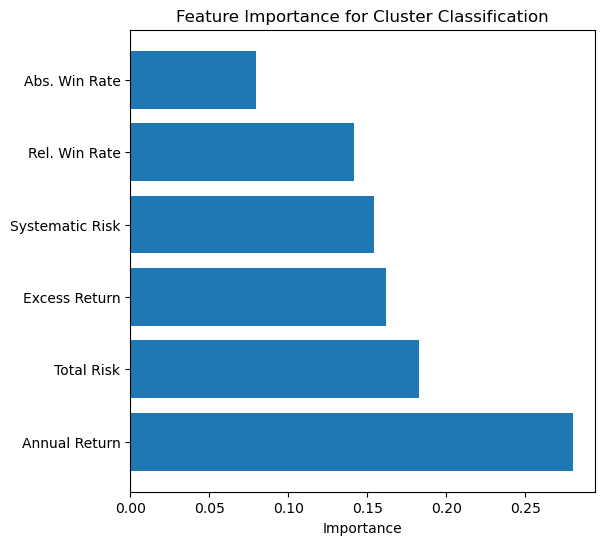

In [36]:
plt.figure(figsize = (6,6))
plt.barh(importance_df['Feature'], importance_df['Importance'])
plt.xlabel('Importance')
plt.title('Feature Importance for Cluster Classification')
plt.show()

In [37]:
# The portfolio groups are seperated strongly by risk patterns than by winning rates.

## 5. Local SHAP values

In [38]:
import shap

In [ ]:
explainer = shap.TreeExplainer(rfc) # in the case of random forest
shap_values = explainer.shap_values(x_train)

### 5.1 Cluster #1

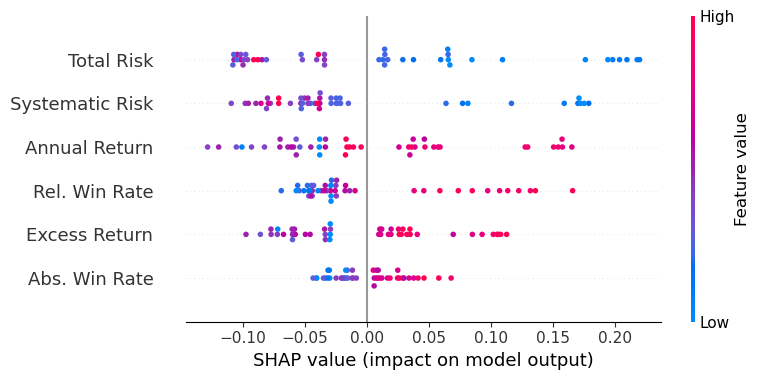

In [41]:
# local shap values for cluster #1
shap.summary_plot(
 shap_values[:, :, 0],
 x_train,
 max_display=10
)

In [ ]:
###### cluster #1 interpretation ######
# "Efficient Low-Risks Portfolios"
# Total Risk: Lower total risk increases the probability of belonging to Cluster #1.
# Systematic Risk: Lower systematic risk increases the probability of belonging to Cluster #1.
# Annual Return: Higher annual return increases the probability of belonging to Cluster #1.
# Relative Win Rate: Higher relative win rate increases the probability of belonging to Cluster #1.
# Excess Return: Higher excess return increases the probability of belonging to Cluster
# Absolute Win Rate: Higher absolute win rate increases the probability of belonging to Cluster #1.

### 5.2 Cluster #2

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


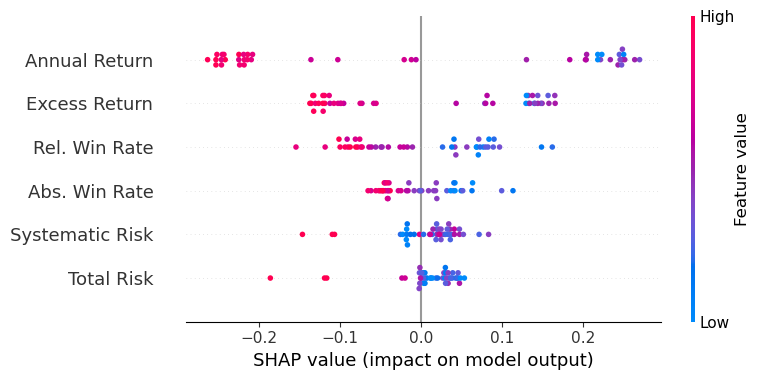

In [46]:
# local shap values for cluster #2
shap.summary_plot(
 shap_values[:, :, 1],
 x_train,
 max_display=10
)

In [ ]:
###### cluster #2 interpretation ######
# "Underperforming Portfolios"
# Annual Return: Lower annual return increases the probability of belonging to Cluster #2.
# Excess Return: Lower excess return increases the probability of belonging to Cluster #2.
# Relative Win Rate: Lower relative win rate increases the probability of belonging to Cluster #2.
# Absolute Win Rate: Lower absolute win rate increases the probability of belonging to Cluster #2.
# Systematic Risk: Has a relatively small influence on Cluster #2.
# Total Risk: Has a relatively small influence on Cluster #2.

### 5.3 Cluster #3

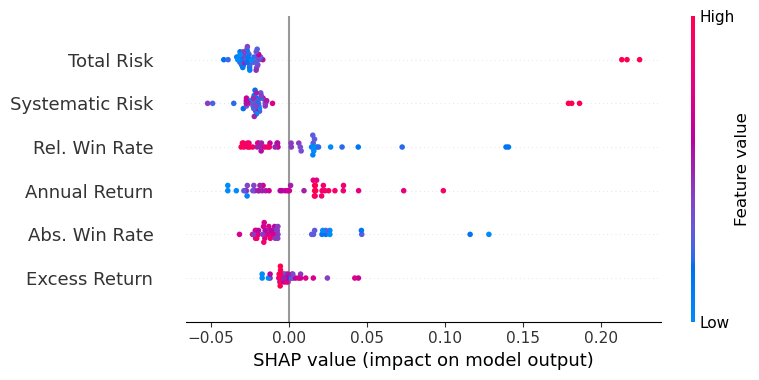

In [44]:
# local shap values for cluster #3
shap.summary_plot(
 shap_values[:, :, 2],
 x_train,
 max_display=10
)

In [ ]:
###### cluster #3 interpretation ######
# "High-Risk Portfolios"
# Total Risk: Higher total risk strongly increases the probability of belonging to Cluster #3.
# Systematic Risk: Higher systematic risk strongly increases the probability of belonging to Cluster #3.
# Relative Win Rate: Lower relative win rate increases the probability of belonging to Cluster #3.
# Annual Return: Higher annual return slightly increases the probability of belonging to Cluster #3.
# Absolute Win Rate: Lower absolute win rate increases the probability of belonging to Cluster #3.
# Excess Return: Higher excess return slightly increases the probability of belonging to Cluster #3.

### 5.4 Cluster #4

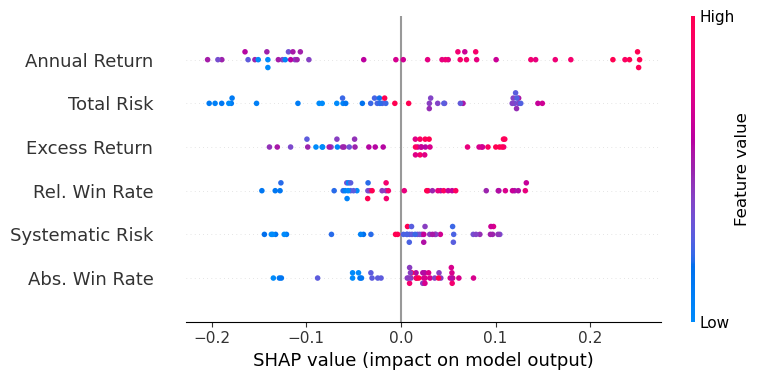

In [45]:
# local shap values for cluster #4
shap.summary_plot(
 shap_values[:, :, 3],
 x_train,
 max_display=10
)

In [ ]:
###### cluster #4 interpretation ######
# "Aggressive Growth Portfolios"
# Annual Return: Higher annual return strongly increases the probability of belonging to Cluster #4.
# Total Risk: Higher total risk increases the probability of belonging to Cluster #4.
# Excess Return: Higher excess return increases the probability of belonging to Cluster #4.
# Relative Win Rate: Higher relative win rate increases the probability of belonging to Cluster #4.
# Systematic Risk: Higher systematic risk increases the probability of belonging to Cluster #4.
# Absolute Win Rate: Higher absolute win rate slightly increases the probability of belonging to Cluster #4.

In [ ]:
###### Patterns discovered #######
# Three main patterns were observed.
# First, risk was one of the most important factors that separated the portfolio groups.
# Second, portfolios with higher returns generally showed higher winning rates.
# Third, some portfolios achieved strong performance with lower risk, while others achieved strong performance with higher risk.
# This shows that different portfolio groups may fit different investor preferences.

In [ ]:
###### What worked well? ######
# The combination of K-means clustering, PCA visualiztion, Random forest classification, and local SHAP method
# interpretation worked well for understanding portfolio characteristics.

# K-means successfully identified four distinct portfolio groups.
# PCA helped visualize the clusters in two dimensions while retaining a large proportion of the information.
# The Random Forest model achieved a testing accuracy of 94.7%. It shows that the clusters were well separated.
# SHAP values provided interpretable explanations of why portfolios belonged to specific clusters.

In [ ]:
###### Limitations ######
# First, the dataset contains only 63 portfolios, which is relatively small for clustering analysis.
# Second, only six performance indicators were used for clustering.
# Although these variables were selected based on the methodology of the reference paper,
# other financial variables may also influence portfolio behavior.